# 🧠 APVC – Desafio 1
## Classificação de Imagens de Roupas com Redes Neuronais Clássicas

### 👥 Grupo G11
- **Bernardo Coelho**, nº 98445  
- **Rafael Alexandre Dias Andorinha**, nº 131000  
- **Nuno Martins**, nº 98863  
- **Pedro Fonte Santa**, nº 105306  

---

📅 **Data de entrega:** 09 de março  
📊 **Objetivo:** Desenvolver modelos de rede neuronal para classificação multiclasse e binária no dataset *FASHION_MNIST*, avaliando desempenho e no final comparar as duas abordagens.

---

# 📌 Parte 2:

In [1]:
# Imports
import tensorflow as tf
from tensorflow import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

2025-03-07 15:47:54.769738: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Constantes - dimensões das imagens
IMG_HEIGHT = 28
IMG_WIDTH = 28

# Constantes - Labels (modificadas para classificação binária)
# 1 = Vestuário (T-shirt, Trouser, Pullover, Dress, Coat)
# 0 = Calçado e Malas (Sandal, Shirt, Sneaker, Bag, Boot)
N_CLASSES = 2
LABELS = ["Vestuário", "Calçado e Malas"]

In [19]:
# Carregar o dataset Fashion MNIST
dataset = keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = dataset.load_data()

# Normalização
x_train = x_train / 255.0
x_test = x_test / 255.0

### a) Novas Labels

In [20]:
# Mapear as classes originais para binárias:
# 1: Vestuário (T-shirt, Trouser, Pullover, Dress, Coat)
# 0: Calçado e Malas (Sandal, Shirt, Sneaker, Bag, Boot)

# Criar um mapeamento para classes binárias
y_train_bin = np.where(np.isin(y_train, [0, 2, 3, 4, 5]), 1, 0)  # 1 é Vestuário
y_test_bin = np.where(np.isin(y_test, [0, 2, 3, 4, 5]), 1, 0)    # 1 é Vestuário

# Verificando a quantidade de amostras de cada classe
print(f"Classes binárias no treino: {np.unique(y_train_bin, return_counts=True)}")
print(f"Classes binárias no teste: {np.unique(y_test_bin, return_counts=True)}")

Classes binárias no treino: (array([0, 1]), array([30000, 30000]))
Classes binárias no teste: (array([0, 1]), array([5000, 5000]))


### b) Construir o modelo e c) Compilar a rede

In [4]:
# Criar o modelo de rede neuronal
model = keras.Sequential([
    layers.Input(shape=(28, 28)),    # Input layer
    layers.Flatten(),                # Flatten para transformar a imagem em vetor
    layers.Dense(128, activation='relu'),  # Camada oculta com 128 neurónios
    layers.Dense(64, activation='relu'),   # Camada oculta com 64 neurónios
    layers.Dense(1, activation='sigmoid')  # Camada de saída (1 neurónio para binário)
])

# Compilação do modelo
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # Função de perda para classificação binária
    metrics=['accuracy']         # Métrica de precisão
)

### d) Treinar o modelo (máximo 50 épocas + callbacks)

**NOTA: Sempre que corrermos o modelo se for encontrada uma configuração de pesos melhor o ficheiro (best_model.weights.h5) é subscrito, caso contrário o ficheiro mantem-se o mesmo** 

In [27]:
# Callbacks
BEST_MODEL_CHECKPOINT = keras.callbacks.ModelCheckpoint(
    filepath="tmp/best_model.weights.h5",  # Ficheiro para os pesos do melhor modelo
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True
)

EARLY_STOPPING = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5
)

# Treinar o modelo com callbacks
history = model.fit(
    x_train, y_train_bin,
    epochs=50,
    batch_size=32,
    validation_split=0.2,  # Usar 20% dos dados de treino para validação
    callbacks=[BEST_MODEL_CHECKPOINT, EARLY_STOPPING]
)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9517 - loss: 0.1158 - val_accuracy: 0.9362 - val_loss: 0.1676
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.9565 - loss: 0.1065 - val_accuracy: 0.9328 - val_loss: 0.1711
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9551 - loss: 0.1063 - val_accuracy: 0.9324 - val_loss: 0.1778
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9568 - loss: 0.1030 - val_accuracy: 0.9352 - val_loss: 0.1729
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9583 - loss: 0.1002 - val_accuracy: 0.9360 - val_loss: 0.1879
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9606 - loss: 0.0961 - val_accuracy: 0.9320 - val_loss: 0.1740


### f) Calcular taxa de acertos no conjunto de teste

In [28]:
# Carregar os melhores pesos do modelo
model.load_weights("tmp/best_model.weights.h5")

# Avaliar o modelo no conjunto de teste
test_loss, test_acc = model.evaluate(x_test, y_test_bin)
print(f"Taxa de acerto no conjunto de teste: {test_acc*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9311 - loss: 0.1755
Taxa de acerto no conjunto de teste: 92.83%


### e) Gerar gráficos da evolução do treino

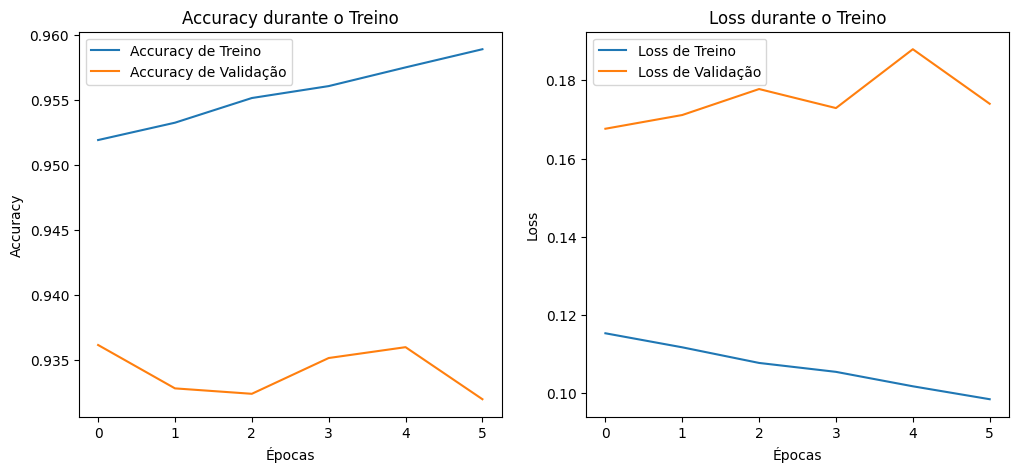

In [29]:
# Gerar gráficos de perda e acurácia
plt.figure(figsize=(12, 5))

# Loss de treino e validação
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss de Treino')
plt.plot(history.history['val_loss'], label='Loss de Validação')
plt.title('Loss durante o Treino')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

# Accuracy de treino e validação
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy de Treino')
plt.plot(history.history['val_accuracy'], label='Accuracy de Validação')
plt.title('Accuracy durante o Treino')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

### g) Matriz de confusão

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


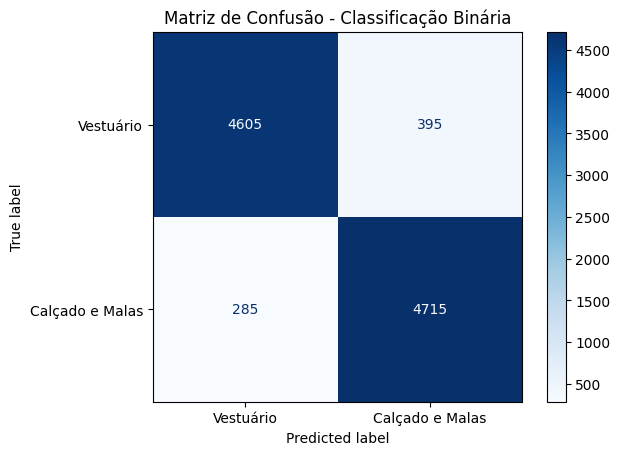

In [18]:
# Predições no conjunto de teste
y_pred = model.predict(x_test)
y_pred_bin = (y_pred > 0.5).astype(int)  # Converte as probabilidades para 0 ou 1

# Gerar a matriz de confusão
cm = confusion_matrix(y_test_bin, y_pred_bin)

# Exibir a matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - Classificação Binária")
plt.show()

# 📌 Parte 3:

### Comparar classificações de ambos os modelos anteriores 
#### (predições multi-classe binarizadas vs. predições binárias diretas)

In [ ]:
# ✅ 2. Abordagem binária direta

# Carregar os melhores pesos da rede binária
model.load_weights("tmp/best_model.weights.h5")

# Avaliar a rede binária diretamente no conjunto de teste binário
loss_binary, accuracy_binary_direct = model.evaluate(x_test, y_test_bin, verbose=0)
print(f"Accuracy da rede binária direta: {accuracy_binary_direct:.4f}")

Accuracy da rede binária direta: 0.9283
